# Probe de decay temprano del learning rate

Este notebook repite únicamente la seed 10 del piloto MLP de escala media. Usa `3e-4` durante las épocas 1–2 y `3e-5` desde la época 3. No construye test y no atribuye este schedule al paper.

El criterio se congela antes de ejecutar: ratio de error final y máximo tardío (épocas 10–20) como máximo `0.5`, rango efectivo del checkpoint al menos `4` y pureza al menos `49%`. Un PASS sólo habilita una corrida de cinco seeds.

In [1]:
# ruff: noqa: E402, E501
import json
import random
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import (
    PaperCheckpointReplayConfig,
    load_paper_mlp_one_hidden_development_config,
)
from koopman_jepa.paper_data import PAPER_REGIME_NAMES, PaperRegimeDataset, generate_paper_master
from koopman_jepa.paper_evaluation import evaluate_paper_mlp_seed_clustering
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    make_paper_loader,
    run_paper_train_validation_with_checkpoint,
    summarize_seed_checkpoint,
    verify_paper_checkpoint_replay,
)

plt.style.use("seaborn-v0_8-whitegrid")
torch.use_deterministic_algorithms(True)

In [2]:
config = load_paper_mlp_one_hidden_development_config(
    ROOT / "configs" / "paper_mlp_step_decay_probe.yaml"
)
selection_gate = replace(config.checkpoint_gate, min_validation_effective_rank=1.0)
replay_config = PaperCheckpointReplayConfig(metric_absolute_tolerance=1e-8)
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
train_keys = {train_dataset.sample_key(i) for i in range(len(train_dataset))}
validation_keys = {validation_dataset.sample_key(i) for i in range(len(validation_dataset))}
assert config.data.train_per_regime == 256
assert config.data.val_per_regime == 64
assert len(train_dataset) == 256 * len(PAPER_REGIME_NAMES) == 4608
assert len(validation_dataset) == 64 * len(PAPER_REGIME_NAMES) == 1152
assert train_keys.isdisjoint(validation_keys)
assert config.sweep.seeds == (10,)
assert config.train.max_gradient_norm is None
assert config.train.learning_rate_schedule == "step"
assert config.train.learning_rate_decay_epoch == 2
assert config.train.learning_rate_decay_factor == 0.1
print(json.dumps(asdict(config), indent=2))
print(f"Train/validation: {len(train_dataset)}/{len(validation_dataset)}. Test no fue instanciado.")

{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 256,
    "val_per_regime": 64,
    "test_per_regime": 64,
    "base_seed": 1,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "direct",
    "predictor_kind": "mlp",
    "linear_initialization": "identity",
    "mlp_depth": "one_hidden",
    "ema_decay": 0.996
  },
  "train": {
    "optimizer": "adamw",
    "learning_rate": 0.0003,
    "weight_decay": 0.0,
    "batch_size": 64,
    "epochs": 20,
    "seed": 10,
    "device": "cpu",
    "num_workers": 0,
    "max_gradient_norm": null,
    "learning_rate_schedule": "step",
    "learning_rate_decay_epoch": 2,
    "learning_rate_decay_factor": 0.1
  },
  "checkpoint_gate": {
    "final_window": 2,
    "max_validation_loss_ratio": 0.5,
    "max_validation_train_loss_ratio": 4.0,
    "min_validation_embedding_std_ratio": 0.1,
    "min_validation_effective_r

In [3]:
seed = config.sweep.seeds[0]
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
run_config = replace(config.train, seed=seed)
model = PaperTemporalJEPA(config.model)
started = time.perf_counter()
run = run_paper_train_validation_with_checkpoint(
    model, train_dataset, validation_dataset, run_config, selection_gate
)
elapsed = time.perf_counter() - started
assert run.selection is not None
replay = verify_paper_checkpoint_replay(
    model, run, validation_dataset, run_config, replay_config, expected_epoch=run.selection.epoch
)
assert replay.passed
summary = summarize_seed_checkpoint(seed, run.selection)
print(f"seed={seed} epoch={summary.checkpoint_epoch} val/base={summary.validation_loss_ratio:.4f} "
      f"gap={summary.validation_train_loss_ratio:.3f} rank={summary.validation_effective_rank:.2f} "
      f"time={elapsed:.1f}s")

seed=10 epoch=2 val/base=0.0151 gap=1.042 rank=7.87 time=147.3s


In [4]:
@torch.no_grad()
def collect_validation_embeddings():
    device = torch.device(run_config.device)
    model.to(device).eval()
    embeddings, labels = [], []
    for context, _, batch_labels in make_paper_loader(validation_dataset, run_config, shuffle=False):
        embeddings.append(model.online_encoder(context.to(device)).cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

embeddings, labels = collect_validation_embeddings()
clustering = evaluate_paper_mlp_seed_clustering(
    embeddings, labels, seed, config.clustering
)
print(json.dumps(asdict(clustering), indent=2))

{
  "seed": 10,
  "mean_purity": 0.5106770833333333,
  "purity_std": 0.009973576804664876,
  "minimum_purity": 0.4826388888888889,
  "maximum_purity": 0.5269097222222222,
  "mean_matched_accuracy": 0.46319444444444446,
  "purities": [
    0.5060763888888888,
    0.5095486111111112,
    0.5225694444444444,
    0.5052083333333334,
    0.5069444444444444,
    0.5008680555555556,
    0.5095486111111112,
    0.5138888888888888,
    0.5,
    0.5095486111111112,
    0.5269097222222222,
    0.515625,
    0.5008680555555556,
    0.5234375,
    0.5225694444444444,
    0.4826388888888889,
    0.5164930555555556,
    0.5173611111111112,
    0.5104166666666666,
    0.5130208333333334
  ],
  "matched_accuracies": [
    0.4644097222222222,
    0.4652777777777778,
    0.4678819444444444,
    0.4626736111111111,
    0.4652777777777778,
    0.4592013888888889,
    0.4644097222222222,
    0.46875,
    0.4565972222222222,
    0.4626736111111111,
    0.4704861111111111,
    0.4696180555555556,
    0.450520

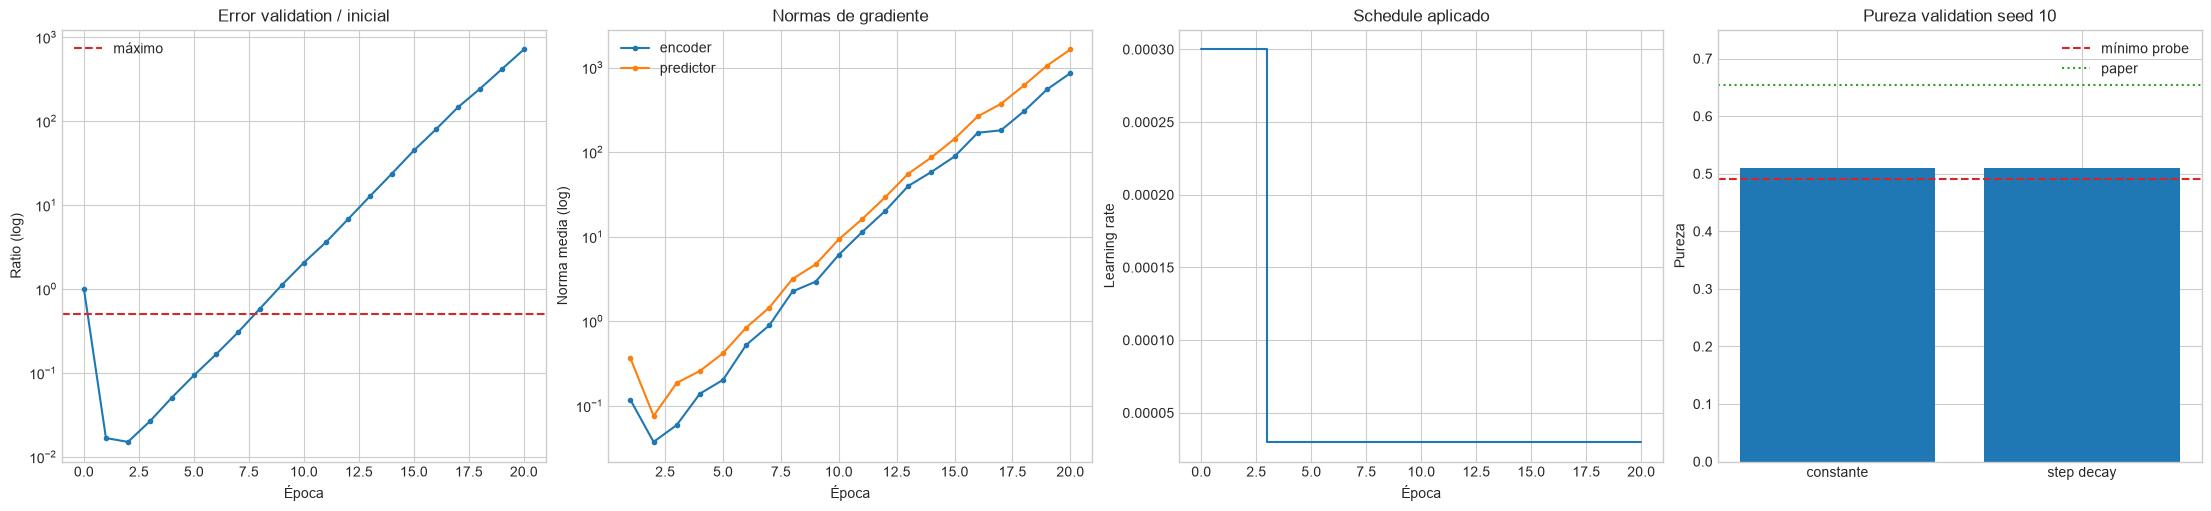

## Análisis del resultado

- Resultado del probe: **FAIL**.
- Ratio final: **715.8364** (constante: `1014.4`; clipping: `1843.0`).
- Máximo ratio entre épocas 10–20: **715.8364**.
- Rango efectivo del checkpoint: **7.87**.
- Pureza: **51.07% ± 1.00%** (constante: `51.07%`).
- Máximas normas medias encoder/predictor: **860.20 / 1641.08**.

Un PASS sólo habilita repetir esta condición en las cinco seeds de desarrollo. No reproduce todavía el `65.48%` del paper y no habilita test.


Test no fue construido ni consultado.


In [5]:
MAX_FINAL_VALIDATION_RATIO = 0.5
MAX_LATE_VALIDATION_RATIO = 0.5
MIN_CHECKPOINT_RANK = 4.0
MIN_MEAN_PURITY = 0.49
BASELINE_SEED10_PURITY = 0.5107
BASELINE_FINAL_VALIDATION_RATIO = 1014.3532
CLIPPED_FINAL_VALIDATION_RATIO = 1843.0214

history = run.history
baseline_loss = history[0].validation_loss
epochs = np.array([row.epoch for row in history])
validation_ratios = np.array([row.validation_loss / baseline_loss for row in history])
online_gradients = np.array([row.online_gradient_norm for row in history])
predictor_gradients = np.array([row.predictor_gradient_norm for row in history])
learning_rates = np.where(epochs <= config.train.learning_rate_decay_epoch, 3e-4, 3e-5)
final_validation_ratio = validation_ratios[-1]
max_late_validation_ratio = validation_ratios[epochs >= 10].max()
probe_passed = bool(
    final_validation_ratio <= MAX_FINAL_VALIDATION_RATIO
    and max_late_validation_ratio <= MAX_LATE_VALIDATION_RATIO
    and summary.validation_effective_rank >= MIN_CHECKPOINT_RANK
    and clustering.mean_purity >= MIN_MEAN_PURITY
)

fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
axes[0].plot(epochs, validation_ratios, marker="o", markersize=3)
axes[0].axhline(MAX_FINAL_VALIDATION_RATIO, color="tab:red", linestyle="--", label="máximo")
axes[0].set_yscale("log")
axes[0].set(title="Error validation / inicial", xlabel="Época", ylabel="Ratio (log)")
axes[0].legend()
axes[1].plot(epochs[1:], online_gradients[1:], marker="o", markersize=3, label="encoder")
axes[1].plot(epochs[1:], predictor_gradients[1:], marker="o", markersize=3, label="predictor")
axes[1].set_yscale("log")
axes[1].set(title="Normas de gradiente", xlabel="Época", ylabel="Norma media (log)")
axes[1].legend()
axes[2].step(epochs, learning_rates, where="post")
axes[2].set(title="Schedule aplicado", xlabel="Época", ylabel="Learning rate")
axes[3].bar(["constante", "step decay"], [BASELINE_SEED10_PURITY, clustering.mean_purity])
axes[3].axhline(MIN_MEAN_PURITY, color="tab:red", linestyle="--", label="mínimo probe")
axes[3].axhline(0.6548, color="tab:green", linestyle=":", label="paper")
axes[3].set(title="Pureza validation seed 10", ylabel="Pureza", ylim=(0.0, 0.75))
axes[3].legend()
plt.show()

display(Markdown(f"""## Análisis del resultado

- Resultado del probe: **{'PASS' if probe_passed else 'FAIL'}**.
- Ratio final: **{final_validation_ratio:.4f}** (constante: `{BASELINE_FINAL_VALIDATION_RATIO:.1f}`; clipping: `{CLIPPED_FINAL_VALIDATION_RATIO:.1f}`).
- Máximo ratio entre épocas 10–20: **{max_late_validation_ratio:.4f}**.
- Rango efectivo del checkpoint: **{summary.validation_effective_rank:.2f}**.
- Pureza: **{clustering.mean_purity:.2%} ± {clustering.purity_std:.2%}** (constante: `{BASELINE_SEED10_PURITY:.2%}`).
- Máximas normas medias encoder/predictor: **{online_gradients[1:].max():.2f} / {predictor_gradients[1:].max():.2f}**.

Un PASS sólo habilita repetir esta condición en las cinco seeds de desarrollo. No reproduce todavía el `65.48%` del paper y no habilita test.
"""))
print("Test no fue construido ni consultado.")